# Clean & Analyze Social Media

## Introduction

Social media has become a ubiquitous part of modern life, with platforms such as Instagram, Twitter, and Facebook serving as essential communication channels. Social media data sets are vast and complex, making analysis a challenging task for businesses and researchers alike. In this project, we explore a simulated social media, for example Tweets, data set to understand trends in likes across different categories.

## Prerequisites

To follow along with this project, you should have a basic understanding of Python programming and data analysis concepts. In addition, you may want to use the following packages in your Python environment:

- pandas
- Matplotlib
- ...

These packages should already be installed in Coursera's Jupyter Notebook environment, however if you'd like to install additional packages that are not included in this environment or are working off platform you can install additional packages using `!pip install packagename` within a notebook cell such as:

- `!pip install pandas`
- `!pip install matplotlib`

## Project Scope

The objective of this project is to analyze tweets (or other social media data) and gain insights into user engagement. We will explore the data set using visualization techniques to understand the distribution of likes across different categories. Finally, we will analyze the data to draw conclusions about the most popular categories and the overall engagement on the platform.

## Step 1: Importing Required Libraries

As the name suggests, the first step is to import all the necessary libraries that will be used in the project. In this case, we need pandas, numpy, matplotlib, seaborn, and random libraries.

Pandas is a library used for data manipulation and analysis. Numpy is a library used for numerical computations. Matplotlib is a library used for data visualization. Seaborn is a library used for statistical data visualization. Random is a library used to generate random numbers.

### Background Info:
###### Social Media Platform: X.com
###### Company: Jamaica Gleaner
###### Type of Company: Multi-media organization (newspaper, radio etc.)
###### No. of Tweets Analyzed: 100

In [1]:
## Install Add. Libraries
!pip install tweepy nltk

You should consider upgrading via the '/opt/conda/bin/python3 -m pip install --upgrade pip' command.


In [2]:
## Import Libraries
import pandas as pd # for data handling
import matplotlib.pyplot as plt # for visualizations
import seaborn as sns # for visualizations
import tweepy # for connecting to Twitter API
from nltk.corpus import stopwords # for stopwords removal
import nltk # for text cleaning

nltk.download('stopwords') # for stopword dataset download
import re # for text cleaning

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
## Twitter API setup
BEARER_TOKEN = "AAAAAAAAAAAAAAAAAAAAALjy6wEAAAAA61slPQLhRuh90RKAkmLBW1lQ2PY%3DX0ejQTBGdtZ1EmwWx9uBDCLDvCDYDINXEXUI8w7GWJxMMxBxIT"

client = tweepy.Client(bearer_token=BEARER_TOKEN)

In [4]:
## Tweets Extraction
company = "JamaicaGleaner"   # Company's X ID
tweet_limit = 100 # no. of tweets to collect

# retrieves co.'s unique Twitter ID
user = client.get_user(username=company) 
user_id = user.data.id

# requests tweets from co.'s account
tweets = client.get_users_tweets( 
    id=user_id,
    max_results=tweet_limit,
    tweet_fields=["public_metrics","created_at"]
)

tweet_list = [] # list to store tweets

# loops through tweets + saves text + stores no. of likes
for t in tweets.data:
    tweet_list.append({
        "text": t.text,
        "likes": t.public_metrics["like_count"]
    })

df = pd.DataFrame(tweet_list) # converts tweet_list to dataframe
df.head() # displays 1st five rows of dataframe (by default)

,text,likes
0,A court has ruled that Clarendon chef Anray Wi...,0
1,The Jamaican economy grew by 5.1 per cent in t...,0
2,"A licensed firearm holder from Spanish Town, S...",1
3,The Government has launched the Shelter Recove...,1
4,The Auditor General’s Department says there is...,2


In [5]:
df.tail() # displays last five rows of dataframe (by default)

,text,likes
95,Seven-year-old Je’Nasiya Mais captured Jamaica...,26
96,Constable Noel Maitland has told a jury that h...,3
97,https://t.co/Qvu39GcG0h,0
98,https://t.co/edEaSiTqoM,1
99,"Today, with input from our panellist, Sean ‘Co...",4


In [6]:
df.info() # displays basic details of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    100 non-null    object
 1   likes   100 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.7+ KB


In [7]:
df.describe() # displays basic details of the 'likes' column (only numeric column)

,likes
count,100.000000
mean,8.650000
std,16.019795
min,0.000000
25%,2.000000
50%,4.000000
75%,7.250000
max,109.000000


Text(0, 0.5, "Proportion of 'Likes'")

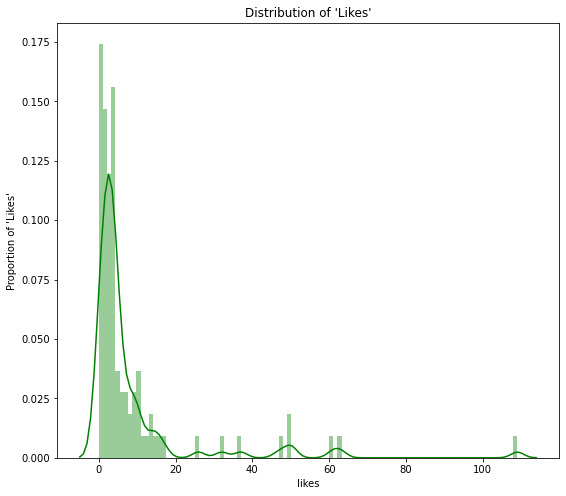

In [9]:
## Distribution Of 'likes' (Histogram)
plt.figure(figsize=(9, 8))
sns.distplot(df['likes'], color='g', bins=100, hist_kws={'alpha': 0.4});
plt.title("Distribution of 'Likes'")
plt.ylabel("Proportion of 'Likes'")

In [10]:
## Data Cleaning
stop_words = set(stopwords.words("english"))

# cleans tweets - removes unimportant characters
def clean_text(text):
    text = re.sub(r"http\S+", "", text) # removes links (replaces with blankspace)
    text = re.sub(r"@\w+", "", text) # removes usernames (replaces with blankspace)
    text = re.sub(r"#", "", text) # removes hashtag (replaces with blankspace)
    text = re.sub(r"[^a-zA-Z ]", "", text) # removes all characters except letters/spaces (replaces with blankspace)
    text = text.lower() # converts text to lowercase
    text = " ".join([w for w in text.split() if w not in stop_words]) # splits tweets & re-joins non-stopwords
    return text

df["clean_text"] = df["text"].apply(clean_text) # stores cleaned tweets into dataframe
df.head()  # displays 1st five rows of dataframe (by default)

,text,likes,clean_text
0,A court has ruled that Clarendon chef Anray Wi...,0,court ruled clarendon chef anray williams accu...
1,The Jamaican economy grew by 5.1 per cent in t...,0,jamaican economy grew per cent july september ...
2,"A licensed firearm holder from Spanish Town, S...",1,licensed firearm holder spanish town st cather...
3,The Government has launched the Shelter Recove...,1,government launched shelter recovery programme...
4,The Auditor General’s Department says there is...,2,auditor generals department says evidence supp...


In [11]:
## Definition of Categories & Words
categories = {
    "entertainment": ["fun", "party", "game", "travel", "vacation", "drink"],
    "news": ["headline", "investigate", "feature", "report", "media"],
    "sports": ["athlete", "win", "compete", "opponent", "victory", "talent", "player"],
    "commentary": ["editorial", "opinion", "comment"],
    "lifestyle": ["family", "kids", "parent", "home", "event", "celebrate", "wedding"],
    "auto": ["automotive", "engine", "warranty", "speed", "efficiency"],
    "arts": ["culture", "style", "colour", "theme", "artist", "theme"],
    "finance": ["financial", "fewer", "greater", "threshold", "business", "break"],
    "food": ["food", "recipe", "eat", "meal", "restaurant", "palate"],
    "health": ["body", "wellness", "heal", "treat", "cure"]
}

In [12]:
## Assign Categories to Tweets
def assign_category(text):
    for cat, words in categories.items():
        for w in words:
            if w in text:
                return cat
    return "other"

df["category"] = df["clean_text"].apply(assign_category) # stores categorized tweets into dataframe
df.head() # displays 1st five rows of dataframe (by default)

,text,likes,clean_text,category
0,A court has ruled that Clarendon chef Anray Wi...,0,court ruled clarendon chef anray williams accu...,lifestyle
1,The Jamaican economy grew by 5.1 per cent in t...,0,jamaican economy grew per cent july september ...,other
2,"A licensed firearm holder from Spanish Town, S...",1,licensed firearm holder spanish town st cather...,other
3,The Government has launched the Shelter Recove...,1,government launched shelter recovery programme...,lifestyle
4,The Auditor General’s Department says there is...,2,auditor generals department says evidence supp...,other


In [13]:
## Analyze Likes by Category
likes_summary = df.groupby("category")["likes"].mean().reset_index() # calculates avg likes + resets index (0, 1, ...)
likes_summary # displays output

,category,likes
0,arts,0.000000
1,commentary,3.666667
2,entertainment,12.142857
3,finance,15.333333
4,food,3.333333
5,health,19.375000
6,lifestyle,3.250000
7,news,3.000000
8,other,9.392157
9,sports,3.555556


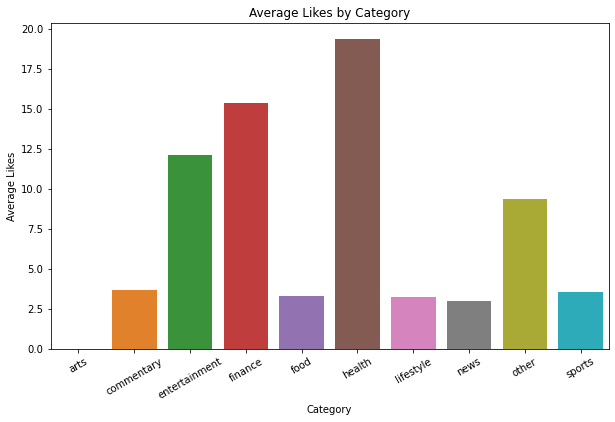

In [14]:
## Visualize Engagement (Barchart)
plt.figure(figsize=(10,6))
sns.barplot(data=likes_summary, x="category", y="likes")
plt.title("Average Likes by Category")
plt.xlabel("Category")
plt.xticks(rotation=30)
plt.ylabel("Average Likes")
plt.show()

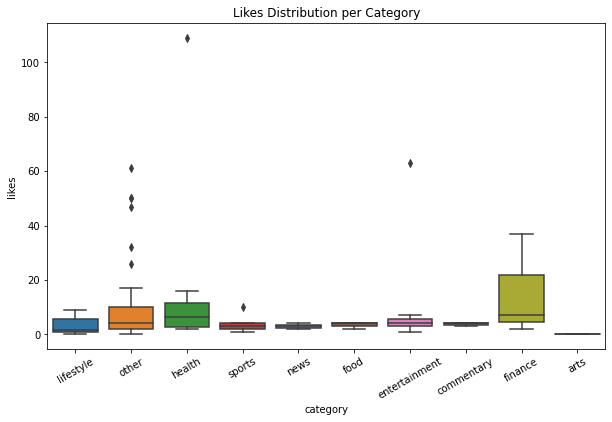

In [15]:
## Engagement Distribution (Boxplot)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="category", y="likes")
plt.xticks(rotation=30)
plt.title("Likes Distribution per Category")
plt.show()

In [16]:
## Conclusions
top_category = likes_summary.sort_values("likes",ascending=False).iloc[0] # stores category w/ highest avg likes

print("Most popular category:", top_category["category"]) # displays category w/ highest likes
print("Average likes:", round(top_category["likes"],2)) # displays avg likes of category

Most popular category: health
Average likes: 19.38


### Analysis Technique Used & Rationale:
###### 1. Descriptive Analysis - Provides some insights into Jamaica Gleaner's X profile i.e 
###### popularity of tweet categories and overall viewer engagement
###### 2. This technique was chosen as the objective of the project was to evaluate the company's present user engagement to direct
###### its social media performance, but not to predict future user engagement.

### Assumptions:
###### Words defined in keyword lists are assumed to be often included in tweets belonging those categories.

### Limitations:
###### 1. Words are not unique across tweets, hence model's categorization of tweets based on keyword lists may be imprecise.
###### 2. A small sample size was used for the analysis, which may not be a true representation of the popularity of the categories 
###### and engagement on the company's X profile
###### 3. Other kinds of user engagement were not measured - no. of views, no. of shares, no. of reposts

### Insights
###### Most tweets had between 0-4 likes (Low Engagement)
###### Most popular categories: Health, Finance & Entertainment
###### Average No. of Likes for Health: 19.38
###### Average No. of Likes for Finance: 15.33
###### Average No. of Likes for Entertainment: 12.14

### Recommendations/Next Steps
###### Company boosts 'likes' on X platform eg. posts more emotion-infused content like anniversary celebrations, birthdays, health recoveries
###### Company prioritizes posts related to Health, Finance & Entertainment as user demand indicates
###### Company revamps other post categories to draw user interests eg. post layout, image/image resolution, wording, timeliness of post